## Coding Exercise #0604a

### Classify the cloth images

In [2]:
# TensorFlow and tf.keras
import tensorflow as tf

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt


#### 1.1.Import the fashion MNIST dataset

In [3]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [4]:
# Each image is mapped to one individual label. Because there's no class name to dataset, save data as separate variables for printing images. 

In [5]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

#### 1.2. Data exploration

In [6]:
train_images.shape

(60000, 28, 28)

In [7]:
len(train_labels)

60000

In [8]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

In [9]:
test_images.shape

(10000, 28, 28)

In [10]:
len(test_labels)

10000

#### 1.3. Data preprocessing

In [11]:
# The first image of train set shows that the scope of pixels is in 0~255.  

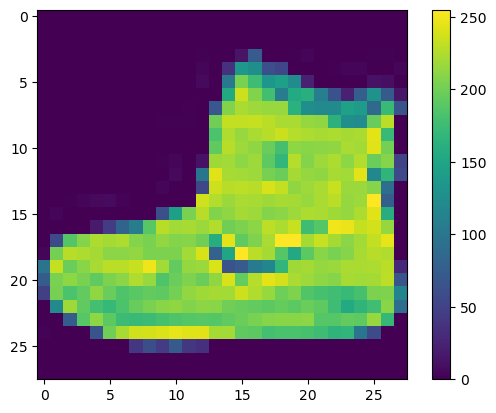

In [12]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

In [13]:
# Before passing into neural network model, set this range to 0~1.

In [14]:
train_images = train_images / 255.0

test_images = test_images / 255.0

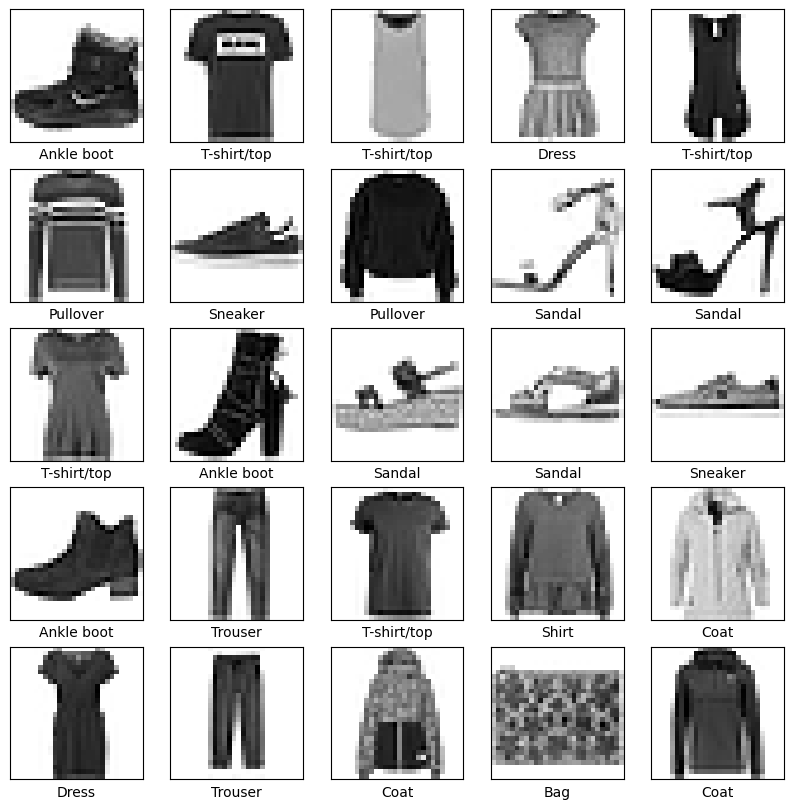

In [15]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

#### 1.4. Create the model

In [16]:
# Set the layers
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

c:\todo\Anaconda\envs\curso_ia\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#### 1.5. Compile the model

In [17]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [18]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

None


#### 1.6. Train the model

In [19]:
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8254 - loss: 0.4967
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8661 - loss: 0.3723
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8772 - loss: 0.3368
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8860 - loss: 0.3125
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8922 - loss: 0.2937
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8959 - loss: 0.2811
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9004 - loss: 0.2701
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9038 - loss: 0.2590
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9074 - loss: 0.2496
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9108 - loss: 0.2407


In [20]:
#### 1.7. Evaluate the accuracy of model
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.8779 - loss: 0.3337

Test accuracy: 0.8779000043869019


#### 1.8. Prediction

In [21]:
probability_model = tf.keras.Sequential([model, 
                                         tf.keras.layers.Softmax()])

In [22]:
predictions = probability_model.predict(test_images)
predictions[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([6.5846586e-07, 3.4315608e-08, 2.0175887e-07, 1.6406656e-12,
       2.7738079e-06, 1.5300807e-03, 3.2287073e-07, 3.8402318e-04,
       3.2026924e-07, 9.9808156e-01], dtype=float32)

In [23]:
np.argmax(predictions[0])

np.int64(9)

In [24]:
test_labels[0]

np.uint8(9)

In [33]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("willianoliveiragibin/modeling-wine")

print("Dataset downloaded to:", path)


files_in_folder = os.listdir(path)
csv_files = [f for f in files_in_folder if f.endswith('.csv')]

if csv_files:
    csv_file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_file_path)
    
    print(f"Successfully loaded: {csv_files[0]}")
    print("First 5 records:")
    print(df.head())
else:
    print("Error: No CSV file found in the dataset folder.")

Dataset downloaded to: C:\Users\alere\.cache\kagglehub\datasets\willianoliveiragibin\modeling-wine\versions\1
Successfully loaded: winequality-white new.csv
First 5 records:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      45.00   
1            6.3              0.30         0.34             1.6      49.00   
2            8.1              0.28         0.40             6.9       0.05   
3            7.2              0.23         0.32             8.5      58.00   
4            7.2              0.23         0.32             8.5      58.00   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0    1.001  3.00       0.45   
1                 14.0                 132.0  994.000  3.30       0.49   
2                 30.0                  97.0    9.951  3.26       0.44   
3                 47.0                 186.0    9.956  3.19  

In [34]:
import kagglehub
import pandas as pd
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

path = kagglehub.dataset_download("willianoliveiragibin/modeling-wine")
files_in_folder = os.listdir(path)
csv_files = [f for f in files_in_folder if f.endswith('.csv')]
csv_file_path = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_file_path)

for col in df.columns:
    if df[col].dtype == 'object':
        if df[col].astype(str).str.contains('R\$').any():
            df[col] = df[col].astype(str).str.replace('R$', '', regex=False)
            df[col] = df[col].str.replace('.', '', regex=False)
            df[col] = df[col].str.replace(',', '.', regex=False)
            df[col] = pd.to_numeric(df[col])

df = pd.get_dummies(df, drop_first=True)

X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(12, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1) 
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.fit(X_train, y_train, epochs=50, validation_split=0.2, verbose=1)

loss, mae = model.evaluate(X_test, y_test)
print(f"Final Result - Mean Absolute Error: {mae:.2f}")

Epoch 1/50


c:\todo\Anaconda\envs\curso_ia\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 22.7272 - mae: 4.5526 - val_loss: 14.7930 - val_mae: 3.5465
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.1114 - mae: 2.5941 - val_loss: 5.6369 - val_mae: 1.9710
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.8004 - mae: 1.7053 - val_loss: 3.6994 - val_mae: 1.5333
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.4135 - mae: 1.4207 - val_loss: 2.7507 - val_mae: 1.3009
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.6204 - mae: 1.2353 - val_loss: 2.2281 - val_mae: 1.1656
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1110 - mae: 1.1110 - val_loss: 1.8481 - val_mae: 1.0526
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7574 - mae: 1.0151 - val_loss: 1.5969 - val_mae: 0.9693
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.5118 - mae: 0.9453 - val_loss: 1.3995 - val_mae: 0.9020
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3316 - mae: 0.8890 - 

In [35]:
import numpy as np

fake_wine = np.array([[7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]])
fake_wine_scaled = scaler.transform(fake_wine)

prediction = model.predict(fake_wine_scaled)

print(f"\n🍷 AI Prediction: This wine has a quality score of: {prediction[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step

🍷 AI Prediction: This wine has a quality score of: 6.29


c:\todo\Anaconda\envs\curso_ia\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


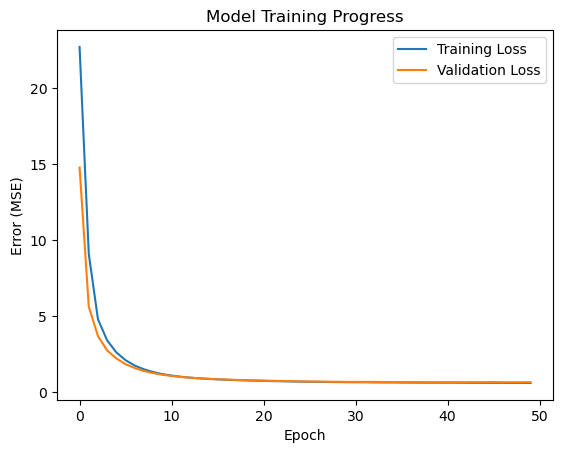

In [37]:
import matplotlib.pyplot as plt

# Plot the Error (Loss) over time
plt.plot(model.history.history['loss'], label='Training Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.title('Model Training Progress')
plt.ylabel('Error (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()
